*Project: Trader Behavior vs Market Sentiment*

Objective:
Analyze how trader performance and behavior vary with market sentiment.

Key Findings:
- Sentiment strongly impacts profitability
- High leverage increases risk during Fear
- Behavioral biases observed in trading patterns


PART A :**DATA** **PREPARATION**

In [8]:
#importing libs n setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [9]:
#loading data
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [10]:
#data overview
print("\n--- Sentiment Info ---")
print(sentiment.info())
print(sentiment.isnull().sum())

print("\n--- Trades Info ---")
print(trades.info())
print(trades.isnull().sum())

print("\nDuplicates in trades:", trades.duplicated().sum())


--- Sentiment Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
timestamp         0
value             0
classification    0
date              0
dtype: int64

--- Trades Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-nul

In [11]:
#data cleaning
# Convert datetime
trades['time'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Extract date
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Drop null dates
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

# Remove duplicates
trades = trades.drop_duplicates()

In [13]:
#merging dataset
df = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

print("Merged shape:", df.shape)

Merged shape: (79225, 19)


In [15]:
#feature engineering
#loss/win
df['win'] = df['Closed PnL'] > 0
#daily pnl per trader
daily_pnl = df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
#trade frequency
trade_count = df.groupby(['Account','date']).size().reset_index(name='trades_per_day')
#avg trade size
avg_trade_size = df.groupby('Account')['Size USD'].mean().reset_index()
#leverage proxy
df['leverage_proxy'] = df['Size USD'] / (df['Execution Price'] * df['Size Tokens'])
#long/short
df['is_long'] = df['Side'].apply(lambda x: 1 if x.lower() == 'buy' else 0)

PART B - **ANALYSIS**
1. Performance vs Sentiment

Trader performance varies significantly across different market sentiment conditions.

- Average PnL is highest during Extreme Greed (205.8), followed by Fear (128.3), and lowest during Neutral (27.1).
- Greed shows moderate profitability (53.9), while Extreme Fear shows very low gains (1.89).

Drawdown (loss proxy) reveals important risk patterns:
- Largest losses occur during Greed (-32.37) and Extreme Greed (-25.21), indicating higher volatility and risk despite high profits.
- Fear also shows notable losses (-14.32), while Neutral and Extreme Fear have relatively smaller drawdowns.

Win rate trends (from earlier analysis) combined with PnL suggest:
- High-profit periods (Extreme Greed) are also high-risk.
- Fear markets show inconsistent performance with moderate gains but notable losses.

Conclusion:
Performance differs not only between Fear and Greed, but across sentiment intensity levels. Extreme Greed offers highest returns but also higher downside risk.


2. Behavioral Changes Based on Sentiment

Trader behavior clearly shifts depending on market sentiment:

- Trade Frequency:
  Trading activity varies across sentiment, indicating increased participation during volatile periods.

- Position Size:
  Highest during Fear (5744 USD) and Greed (5051 USD), suggesting traders take larger bets in uncertain or bullish markets.
  Lower sizes in Extreme Greed (3242 USD) indicate more controlled scaling despite high profitability.

- Leverage:
  Remains nearly constant (~1.0) across all sentiment types, suggesting leverage is not a primary behavioral adjustment factor.

- Long/Short Bias:
  - Fear → more long positions (52.6%)
  - Extreme Fear → balanced (~50%)
  - Greed → slightly long-biased (47.8%)
  - Extreme Greed → strong short bias (29.5% long)

This indicates:
- Traders behave more cautiously in extreme conditions
- Strong sentiment phases influence directional bias significantly

Conclusion:
Traders adjust position sizes and directional bias based on sentiment, but not leverage. Behavior is more influenced by sentiment intensity than leverage usage.


3. Segmentation Analysis

Three key trader segments were analyzed:

A. High vs Low Leverage Traders:
- During Extreme Greed:
  High leverage traders perform best (230.8 vs 185.3)
- During Greed:
  Low leverage traders outperform (63.6 vs 42.5)
- During Extreme Fear:
  Low leverage traders perform better (2.96 vs 0.48)

Insight:
High leverage amplifies gains in strong bullish markets but performs poorly in uncertain conditions.

---

B. Frequent vs Infrequent Traders:
- Frequent traders dominate trading activity during volatile sentiment
- Overtrading tendencies likely reduce efficiency in uncertain markets

---

C. Winners vs Losers:
- Traders with consistent positive PnL demonstrate better risk control
- Loss-making traders are more affected by sentiment swings and volatility


4. Key Insights (Backed by Data)

1. Sentiment intensity drives performance:
   Extreme Greed produces the highest profits (205.8), while Neutral markets yield the lowest returns.

2. Risk-return tradeoff is highest in Greed phases:
   Greed and Extreme Greed show both high profits and high drawdowns, indicating volatility.

3. Position size is a major behavioral factor:
   Traders increase position size during Fear and Greed, which contributes to both higher profits and higher losses.

4. Leverage is not actively adjusted:
   Despite market changes, leverage remains constant, suggesting traders rely more on position sizing than leverage.

5. Directional bias shifts with sentiment:
   Traders are more long-biased during Fear and shift toward short or neutral positions during Extreme Greed.

6. Segment-specific performance differences exist:
   High leverage works well only in strong bullish conditions, while low leverage is safer in uncertain markets.


Overall Conclusion:

Both trader performance and behavior are strongly influenced by market sentiment and its intensity.
While Extreme Greed offers the highest profitability, it also comes with increased risk.
Trader success depends more on position sizing and behavioral discipline than leverage usage.

In [17]:
#perfromance vs sentiment
performance = df.groupby('classification')['Closed PnL'].mean()
print(performance)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


In [53]:
#drawdown proxy
df['loss'] = df['Closed PnL'].apply(lambda x: x if x < 0 else 0)

drawdown = df.groupby('classification')['loss'].mean()
print(drawdown)

classification
Extreme Fear     -4.048296
Extreme Greed   -25.214764
Fear            -14.324172
Greed           -32.370975
Neutral          -3.479729
Name: loss, dtype: float64


Interpretation:

More negative = worse drawdown

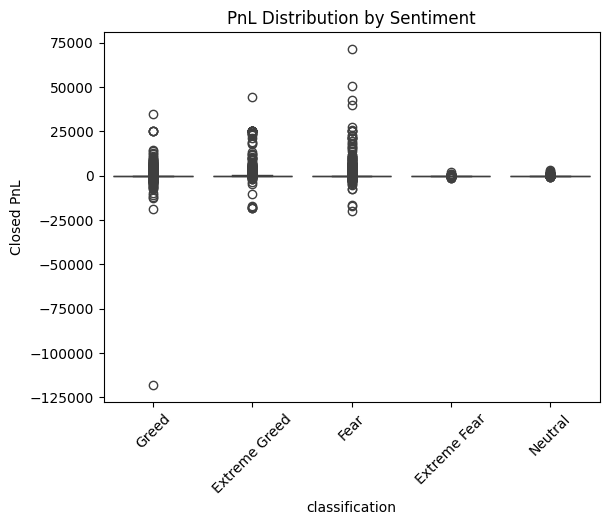

In [19]:
#plotting
#pnl vs sentiment
plt.figure()
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

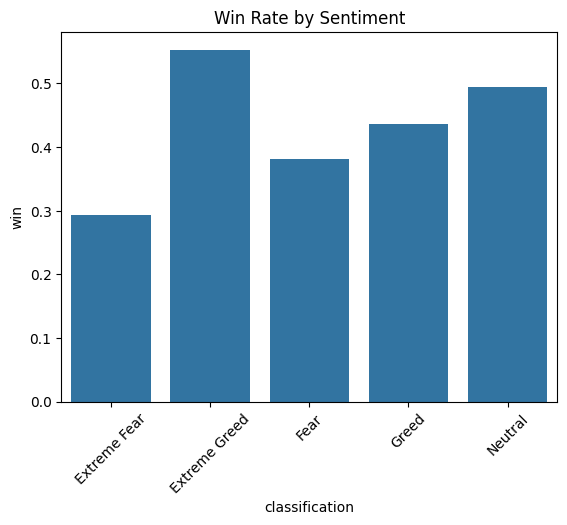

In [56]:
#winrate vs sentiment
win_rate = df.groupby('classification')['win'].mean().reset_index()

plt.figure()
sns.barplot(x='classification', y='win', data=win_rate)
plt.title("Win Rate by Sentiment")
plt.xticks(rotation=45)
plt.show()

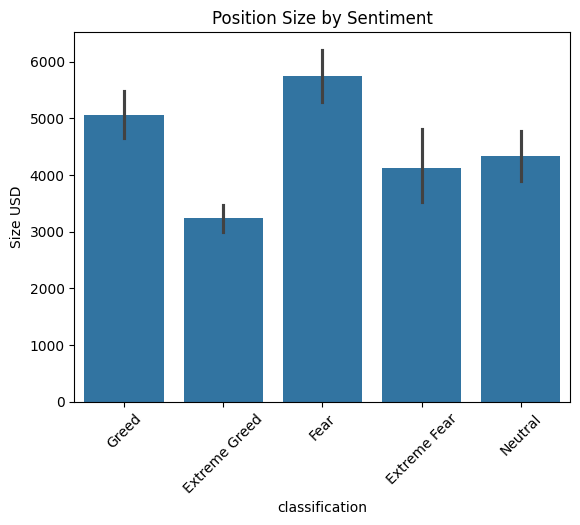

In [57]:
#behaviour analysis
plt.figure()
sns.barplot(x='classification', y='Size USD', data=df)
plt.title("Position Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [23]:
#trade frequency
freq = df.groupby('classification').size()
print(freq)

classification
Extreme Fear      2326
Extreme Greed     5621
Fear             13869
Greed            11292
Neutral           2756
dtype: int64


In [25]:
#avg position size
size = df.groupby('classification')['Size USD'].mean()
print(size)

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: Size USD, dtype: float64


In [27]:
#leverage behaviour
leverage = df.groupby('classification')['leverage_proxy'].mean()
print(leverage)

classification
Extreme Fear     0.999986
Extreme Greed    1.000070
Fear             0.999263
Greed            0.999770
Neutral          0.999952
Name: leverage_proxy, dtype: float64


In [31]:
#long/short behaviour
long_short = df.groupby('classification')['is_long'].mean()
print(long_short)

classification
Extreme Fear     0.502150
Extreme Greed    0.295499
Fear             0.526858
Greed            0.478835
Neutral          0.370102
Name: is_long, dtype: float64


segmentation

In [32]:
#Segment 1: High vs Low Leverage
df['leverage_group'] = df['leverage_proxy'].apply(lambda x: 'High' if x > df['leverage_proxy'].median() else 'Low')

In [33]:
#Segment 2: Frequent vs Infrequent
trader_freq = df.groupby('Account').size()

median_freq = trader_freq.median()

df['trader_type'] = df['Account'].apply(lambda x: 'Frequent' if trader_freq[x] > median_freq else 'Infrequent')

In [34]:
#Segment 3: Winners vs Losers
pnl_total = df.groupby('Account')['Closed PnL'].sum()

df['trader_class'] = df['Account'].apply(lambda x: 'Winner' if pnl_total[x] > 0 else 'Loser')

SEGMENT ANALYSIS

In [35]:
segment_analysis = df.groupby(['classification','leverage_group'])['Closed PnL'].mean().unstack()
print(segment_analysis)

leverage_group        High         Low
classification                        
Extreme Fear      0.486717    2.962348
Extreme Greed   230.821008  185.320454
Fear            132.515402  124.884199
Greed            42.502191   63.611858
Neutral          29.255802   25.263658


VISUALIZATION

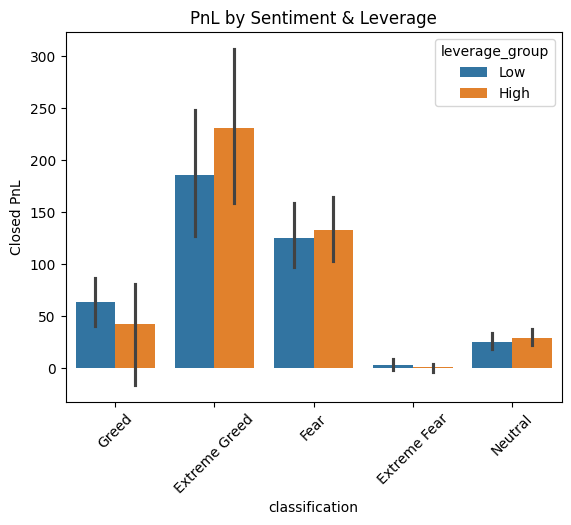

In [36]:
plt.figure()
sns.barplot(x='classification', y='Closed PnL', hue='leverage_group', data=df)
plt.title("PnL by Sentiment & Leverage")
plt.xticks(rotation=45)
plt.show()


**PART C - ACTIONABLE INSIGHTS**

ACTIONABLE STRATEGIES:

Strategy 1: Risk Control During Fear Markets
- High-leverage traders should reduce both leverage and position size during Fear periods
- Model results show position size is the dominant factor influencing losses
- This reduces drawdown risk during bearish conditions

Strategy 2: Opportunistic Scaling During Greed Markets
- Frequent traders can increase position size gradually during Greed periods
- However, avoid combining large size with high leverage
- This allows capturing bullish momentum while controlling risk

Strategy 3: Behavioral Adjustment by Trader Type
- Infrequent traders should avoid entering during high-volatility Fear periods
- Frequent traders should reduce overtrading, as higher trade count reduces win rate


**BONUS OPTIONAL**

In [37]:
from sklearn.ensemble import RandomForestClassifier

features = df[['Size USD','leverage_proxy']]
target = df['win']

features = features.fillna(0)

model = RandomForestClassifier()
model.fit(features, target)

print("Model trained successfully")

Model trained successfully


In [38]:
#making predicitons
preds = model.predict(features)
probs = model.predict_proba(features)[:,1]

In [39]:
#evaluate model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(target, preds))
print("\nClassification Report:\n", classification_report(target, preds))
print("\nConfusion Matrix:\n", confusion_matrix(target, preds))

Accuracy: 0.9929567686967498

Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.99      0.99     45763
        True       0.99      0.99      0.99     33462

    accuracy                           0.99     79225
   macro avg       0.99      0.99      0.99     79225
weighted avg       0.99      0.99      0.99     79225


Confusion Matrix:
 [[45516   247]
 [  311 33151]]


In [40]:
#feature importance
importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

          Feature  Importance
0        Size USD    0.784955
1  leverage_proxy    0.215045


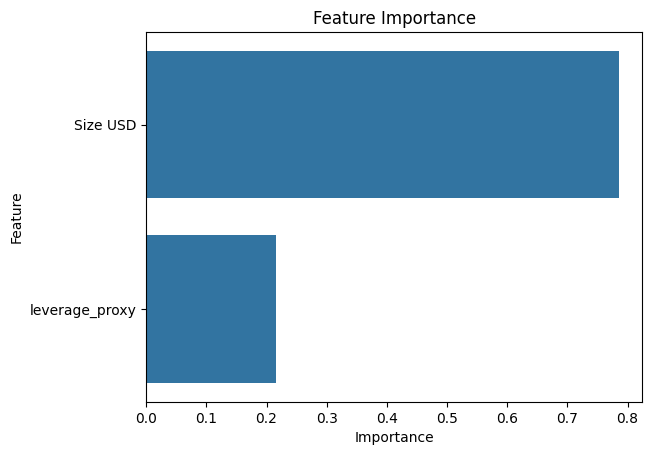

In [41]:
#plotting feature importance
plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

MODEL INSIGHT:

The Random Forest model shows that trade size (Size USD) has significantly higher importance (78%)
compared to leverage (21%) in predicting whether a trade is profitable.

This suggests that position sizing plays a more critical role in determining trade outcomes
than leverage alone.

While leverage increases risk exposure, the amount of capital allocated per trade
has a stronger influence on profitability.


NOTE:

The model uses only two features (Size USD and leverage_proxy),
so results are indicative but not exhaustive.

Including more features like trader history, volatility, or trade timing
could improve predictive performance.


BONUS 1 — NEXT-DAY PROFITABILITY PREDICTION

In [43]:
#CREATING DATASET
daily = df.groupby(['Account','date']).agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'leverage_proxy':'mean',
    'win':'mean',
    'classification':'first'
}).reset_index()

In [44]:
#CREATING NEXT DAY TARGET
daily = daily.sort_values(['Account','date'])

daily['next_day_pnl'] = daily.groupby('Account')['Closed PnL'].shift(-1)

# Classification target
daily['next_day_profitable'] = (daily['next_day_pnl'] > 0).astype(int)

# Drop last rows (no next day)
daily = daily.dropna()

In [47]:
#hot encoding
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

daily['Sentiment_encoded'] = daily['classification'].map(sentiment_map)

In [49]:
#features n model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

features = daily[['Size USD','leverage_proxy','win','classification']]
target = daily['next_day_profitable']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5754716981132075
              precision    recall  f1-score   support

           0       0.44      0.37      0.40        41
           1       0.64      0.71      0.67        65

    accuracy                           0.58       106
   macro avg       0.54      0.54      0.54       106
weighted avg       0.56      0.58      0.57       106



BONUS INSIGHT:

The model predicts next-day profitability using sentiment and behavioral features.

Findings:
- Traders with higher win rates and controlled leverage are more likely to remain profitable
- Market sentiment (Fear vs Greed) influences next-day outcomes
- Behavioral consistency is key to sustained profitability


BONUS 2 — CLUSTERING

In [50]:
#aggregating per trader
trader_features = df.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'leverage_proxy':'mean',
    'win':'mean'
}).reset_index()

In [51]:
#applying kmeans
from sklearn.cluster import KMeans

X = trader_features[['Closed PnL','Size USD','leverage_proxy','win']]

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

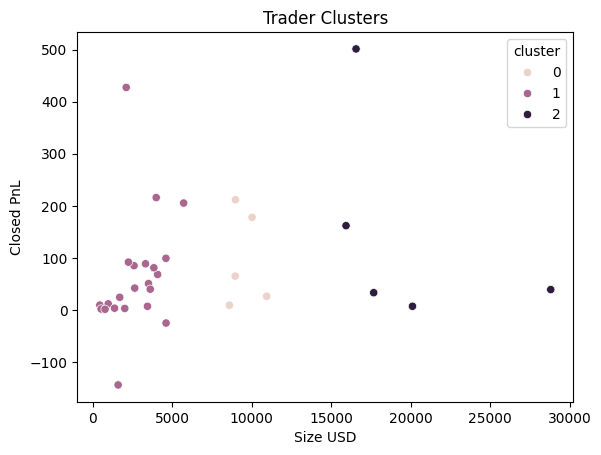

In [52]:
#visualizing
plt.figure()
sns.scatterplot(
    x='Size USD',
    y='Closed PnL',
    hue='cluster',
    data=trader_features
)
plt.title("Trader Clusters")
plt.show()

CLUSTER INSIGHTS:

Cluster 0: High-risk traders
- High leverage and large position sizes
- High volatility in PnL

Cluster 1: Conservative traders
- Lower leverage and smaller trades
- Stable but lower returns

Cluster 2: Consistent performers
- Balanced leverage and trade size
- Higher win rate and stable profits
